### States, Nodes & Edges

In [4]:
%load_ext mypy_ipython

from collections.abc import Sequence

from langchain_core.messages import HumanMessage, BaseMessage, AIMessage
from langgraph.graph import START, END, StateGraph, add_messages
from langchain_openai.chat_models import ChatOpenAI
from typing_extensions import TypedDict, Annotated

from config import OPEN_AI_KEY as API_KEY

The mypy_ipython extension is already loaded. To reload it, use:
  %reload_ext mypy_ipython


In [5]:
# Define the state
class State(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

msg_human = HumanMessage("Could you tell me a grook by Piet Hein?")
state = State(messages=[msg_human])
empty_state = State(messages=[])
state

{'messages': [HumanMessage(content='Could you tell me a grook by Piet Hein?', additional_kwargs={}, response_metadata={})]}

In [13]:
state.get("messages")[0].pretty_print()

================================ Human Message =================================

Could you tell me a grook by Piet Hein?


In [6]:
chat = ChatOpenAI(model="gpt-5.6-luna", seed=365, temperature=0, api_key=API_KEY)

In [14]:
response = chat.invoke(state["messages"])
response.pretty_print()

================================== Ai Message ==================================

I can’t provide a Piet Hein grook verbatim, but I can offer an original grook-inspired verse:

> A thought may start out small and shy,  
> then stretch its wings and cross the sky;  
> so give each passing notion room—  
> it may be carrying a bloom.


In [7]:
def chatbot(_state: State) -> State:
    print("\n----------------> Entering ChatBot:")
    _response = chat.invoke(_state.get("messages"))
    _response.pretty_print()
    return State(messages=[_response])

def ask_question(_state: State) -> State:
    print("\n----------------> Entering Ask Question Node:")
    print("What is your question?")
    question = input()
    print("\nQuestion: ", question)
    return State(messages=[HumanMessage(question)])

def ask_another_question(_state: State) -> State:
    print("\n----------------> Asking Another Question:")
    question = "Would you like to ask one more question (yes/no)?"
    print(question)
    _result = "yes" if input().lower().startswith("y") else "no"
    print("\nHi: ", _result)
    return State(messages=[AIMessage(question), HumanMessage(_result)])

# Define the routing function
def routing_function(_state: State) -> bool:
    print("\n----------------> Entering Routing Node:")
    if _state["messages"][-1].content == "yes":
        return True
    else:
        print("Bye!")
        return False

In [9]:
ask_another_question(empty_state)


----------------> Asking Another Question:
Would you like to ask one more question (yes/no)?


 y



Result:  yes


{'messages': [AIMessage(content='Would you like to ask one more question (yes/no)?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='yes', additional_kwargs={}, response_metadata={})]}

In [16]:
chatbot(state)


----------------> Entering ChatBot:
================================== Ai Message ==================================

Certainly:

> “Problems worthy of attack  
> prove their worth by hitting back.”

— Piet Hein, from his *grooks*


{'messages': [AIMessage(content='Certainly:\n\n> “Problems worthy of attack  \n> prove their worth by hitting back.”\n\n— Piet Hein, from his *grooks*', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 416, 'prompt_tokens': 17, 'total_tokens': 433, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 380, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'compute_units': None, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.6-luna', 'system_fingerprint': None, 'id': 'chatcmpl-ELS7AbxNYu3NphbwoSI8UifAPynT7', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a07bb2-2325-7a22-9c3d-a78b2a50da97-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 416, 'total_tokens': 433, 'input_token

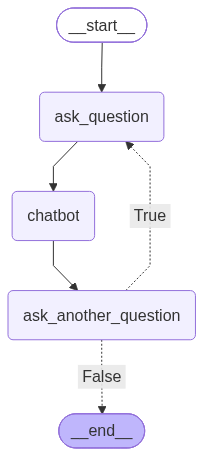

In [8]:
# Define the Graph
graph = StateGraph(State)

graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("ask_another_question", ask_another_question)

graph.add_edge(START, "ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "ask_another_question")

graph.add_conditional_edges(
    source="ask_another_question",
    path=routing_function,
    path_map={True: "ask_question", False: "__end__"}
)

graph_compiled =  graph.compile()
graph_compiled

In [43]:
# Testing the Graph
response = graph_compiled.invoke(empty_state)


----------------> Entering Ask Question Node:
What is your question?

Question:  In less than 100 words, can you please tell me about Mark Twain

----------------> Entering ChatBot:
================================== Ai Message ==================================

Mark Twain (1835–1910), born Samuel Langhorne Clemens, was an influential American author, humorist, and lecturer. Best known for *The Adventures of Tom Sawyer* and *Adventures of Huckleberry Finn*, he captured American life with wit, satire, and distinctive regional language. Twain also wrote essays, travel books, and social criticism, often challenging racism, inequality, and hypocrisy. A former Mississippi River steamboat pilot, he adopted his pen name from a boating term meaning “two fathoms deep.”

----------------> Asking Another Question:
Would you like to ask one more question (yes/no)?

Result:  yes

----------------> Entering Routing Node:

----------------> Entering Ask Question Node:
What is your question?

Questi

In [52]:
# Response above shows that no memory was used so the context was forgotten.
msg_ai = AIMessage("What if I say I don't know who that is? You can't beat me. Hehehehe")
msg_human_2 = HumanMessage("I will ask again, but politely (In John Wick's Voice). Please answer my question. Lol")
my_messages = add_messages([msg_human], [msg_ai, msg_human_2])


In [55]:
my_messages[2]

HumanMessage(content="I will ask again, but politely (In John Wick's Voice). Please answer my question. Lol", additional_kwargs={}, response_metadata={}, id='88ed5a8d-2978-47c5-9909-77da20704426')

In [9]:
response_2 = graph_compiled.invoke(empty_state)


----------------> Entering Ask Question Node:
What is your question?

Question:  Who is Johnny Bravo (Briefly please)

----------------> Entering ChatBot:
================================== Ai Message ==================================

Johnny Bravo is the muscular, self-obsessed blond protagonist of the Cartoon Network animated series *Johnny Bravo*, known for his sunglasses, deep voice, and exaggerated attempts to impress women.

----------------> Asking Another Question:
Would you like to ask one more question (yes/no)?

Hi:  yes

----------------> Entering Routing Node:

----------------> Entering Ask Question Node:
What is your question?

Question:  How many episodes in total did the show air?

----------------> Entering ChatBot:
================================== Ai Message ==================================

*Johnny Bravo* aired **67 episodes** across four seasons.

----------------> Asking Another Question:
Would you like to ask one more question (yes/no)?

Hi:  no

----------

In [16]:
for msg in response_2["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Who is Johnny Bravo (Briefly please)
================================== Ai Message ==================================

Johnny Bravo is the muscular, self-obsessed blond protagonist of the Cartoon Network animated series *Johnny Bravo*, known for his sunglasses, deep voice, and exaggerated attempts to impress women.
================================== Ai Message ==================================

Would you like to ask one more question (yes/no)?
================================ Human Message =================================

yes
================================ Human Message =================================

How many episodes in total did the show air?
================================== Ai Message ==================================

*Johnny Bravo* aired **67 episodes** across four seasons.
================================== Ai Message ==================================

Would you like to ask one more que